In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [2]:
# parameters
region_level = "nuts4"
year = 2017

**A1 - correlation matrix**

In [27]:
# load data
corr_df = pd.read_csv(f"../data/oc09_2023_aug/cor_table_{region_level}_full.csv", sep=";")

In [28]:
# row names are missing -- use column names
corr_df.index = corr_df.columns

# manual selection and reorder
corr_df = corr_df[["egk_coagg", "egk_coagg_mne", "egk_coagg_local", "coagg_porter", "coagg_porter_mne", "coagg_porter_local", "coagg_porter_mne_local"]]

corr_df

,egk_coagg,egk_coagg_mne,egk_coagg_local,coagg_porter,coagg_porter_mne,coagg_porter_local,coagg_porter_mne_local
egk_coagg,1.000000,0.325935,0.455630,0.312990,0.210798,0.169555,0.192903
coagg,0.400802,0.125110,0.238797,0.732894,0.185703,0.474281,0.309142
coagg_porter,0.312990,0.114106,0.240511,1.000000,0.262000,0.740539,0.406054
egk_coagg_mne,0.325935,1.000000,0.017055,0.114106,0.565258,0.030697,0.054843
egk_coagg_local,0.455630,0.017055,1.000000,0.240511,0.039397,0.315869,0.060763
coagg_mne,0.231305,0.669874,0.015075,0.184163,0.817290,0.095311,0.141095
coagg_local,0.163296,0.021217,0.429886,0.457422,0.053322,0.718585,0.116407
coagg_mne_local,0.199666,0.037580,0.047311,0.290239,0.149240,0.137165,0.781617
coagg_porter_mne,0.210798,0.565258,0.039397,0.262000,1.000000,0.151963,0.263662
coagg_porter_local,0.169555,0.030697,0.315869,0.740539,0.151963,1.000000,0.231307


In [21]:
# manual rename
corr_df = corr_df.rename(columns={"egk_coagg":"EGK coagg", "egk_coagg_mne":"EGK coagg MNE x MNE"})

In [22]:
corr_df

,EGK coagg,coagg,coagg_porter,EGK coagg MNE x MNE,egk_coagg_local,coagg_mne,coagg_local,coagg_mne_local,coagg_porter_mne,coagg_porter_local,coagg_porter_mne_local,log_undir_value,sr_norm
egk_coagg,1.000000,0.400802,0.312990,0.325935,0.455630,0.231305,0.163296,0.199666,0.210798,0.169555,0.192903,0.039868,0.082852
coagg,0.400802,1.000000,0.732894,0.125110,0.238797,0.212251,0.512525,0.352882,0.185703,0.474281,0.309142,-0.036856,0.160153
coagg_porter,0.312990,0.732894,1.000000,0.114106,0.240511,0.184163,0.457422,0.290239,0.262000,0.740539,0.406054,0.064802,0.211838
egk_coagg_mne,0.325935,0.125110,0.114106,1.000000,0.017055,0.669874,0.021217,0.037580,0.565258,0.030697,0.054843,0.043423,0.060437
egk_coagg_local,0.455630,0.238797,0.240511,0.017055,1.000000,0.015075,0.429886,0.047311,0.039397,0.315869,0.060763,0.036359,0.063893
coagg_mne,0.231305,0.212251,0.184163,0.669874,0.015075,1.000000,0.062734,0.134610,0.817290,0.095311,0.141095,0.039458,0.073926
coagg_local,0.163296,0.512525,0.457422,0.021217,0.429886,0.062734,1.000000,0.127261,0.053322,0.718585,0.116407,-0.056845,0.141050
coagg_mne_local,0.199666,0.352882,0.290239,0.037580,0.047311,0.134610,0.127261,1.000000,0.149240,0.137165,0.781617,0.005801,0.076410
coagg_porter_mne,0.210798,0.185703,0.262000,0.565258,0.039397,0.817290,0.053322,0.149240,1.000000,0.151963,0.263662,0.170664,0.090559
coagg_porter_local,0.169555,0.474281,0.740539,0.030697,0.315869,0.095311,0.718585,0.137165,0.151963,1.000000,0.231307,0.061769,0.188405


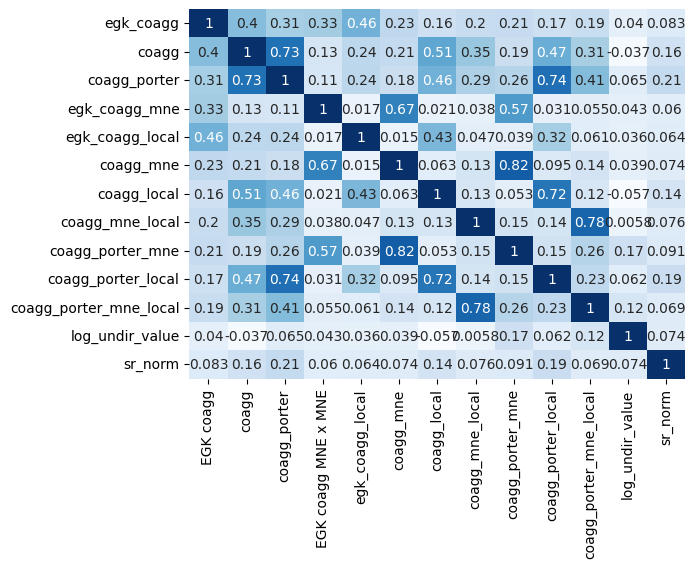

In [23]:
def correlation_matrix(data, key_columns, labels, ax=None):
    """create heatmap from correlation matrix"""
    if ax is None:
        ax = plt.gca()
    sns.heatmap(corr_df, cbar=False, annot=True, cmap="Blues", ax=ax)
    #ax.set_xticklabels(labels)
    #ax.set_yticklabels(labels)

labels = ["EGK coagg", "M_coagg", "M_coagg MNE", "M_coagg domestic", "M_coagg MNE x domestic"]
correlation_matrix(corr_df, key_columns=["egk_coagg", "coagg", "coagg_mne", "coagg_local", "coagg_mne_local"], labels=labels)

**A2 - foreign-owned and domestic companies**